# 개포4동 구역별 분석

구역 정의
* **1구역** : 논현로 2길 ~ 10길 (짝수)
* **2구역** : 논현로 12길 ~ 20길 (짝수) + 개포로 20길
* **3구역** : 개포로 짝수 22길 ~ 40길
* **4구역** : 개포로 홀수 5길 ~ 31길

## 0. 설정

In [1]:
import re
import datetime as dt
import polars as pl
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import platform
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

DATA_PATH = "data.csv"
BASE_YEAR = 2024
BASE_MONTH = 3
CURRENT_YEAR = dt.datetime.now().year
REGIONS = ["1구역", "2구역", "3구역", "4구역"]
REGION_COLORS = {"1구역": "steelblue", "2구역": "darkorange", "3구역": "seagreen", "4구역": "crimson"}

## 1. 데이터 로드 및 구역 분류

In [2]:
def classify_region(road: str) -> str | None:
    m = re.search(r'논현로(\d+)길', road)
    if m:
        n = int(m.group(1))
        if n % 2 == 0 and 2 <= n <= 10:
            return "1구역"
        if n % 2 == 0 and 12 <= n <= 20:
            return "2구역"
        return None
    m = re.search(r'개포로(\d+)길', road)
    if m:
        n = int(m.group(1))
        if n == 20:
            return "2구역"
        if n % 2 == 0 and 22 <= n <= 40:
            return "3구역"
        if n % 2 == 1 and 5 <= n <= 31:
            return "4구역"
        return None
    return None

def load_data(path: str) -> pl.DataFrame:
    df = pl.read_csv(path)
    return (
        df.filter(pl.col("거래유형") == "중개거래")
        .with_columns(
            pl.col("거래금액(만원)").str.replace_all(",", "").cast(pl.Int64).alias("price")
        )
        .with_columns(
            (pl.col("본번").cast(pl.Utf8) + "-" + pl.col("부번").cast(pl.Utf8)).alias("building_id")
        )
        .with_columns(
            (
                (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4).cast(pl.Int64) - BASE_YEAR) * 12
                + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2).cast(pl.Int64)
                - BASE_MONTH
            ).alias("time_idx")
        )
        .with_columns(
            (pl.col("계약년월").cast(pl.Utf8).str.slice(0, 4) + "-"
             + pl.col("계약년월").cast(pl.Utf8).str.slice(4, 2)).alias("ym")
        )
        .with_columns(
            (CURRENT_YEAR - pl.col("건축년도")).alias("age"),
            (pl.col("층") < 0).cast(pl.Int8).alias("is_basement")
        )
        .rename({"전용면적(㎡)": "area", "대지권면적(㎡)": "land_area", "층": "floor"})
        .filter((pl.col("매도자") == "개인") & (pl.col("매수자") == "개인"))
        .filter(pl.col("area") <= 60)
        .with_columns(
            pl.col("도로명").map_elements(classify_region, return_dtype=pl.Utf8).alias("region")
        )
        .filter(pl.col("region").is_not_null())
    )

df = load_data(DATA_PATH)

print(f"개포4동 중개거래 + 개인↔개인: {len(df)}건")
print(df.group_by("region").agg(pl.len().alias("n")).sort("region"))

개포4동 중개거래 + 개인↔개인: 282건
shape: (4, 2)
┌────────┬─────┐
│ region ┆ n   │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ 1구역  ┆ 96  │
│ 2구역  ┆ 75  │
│ 3구역  ┆ 47  │
│ 4구역  ┆ 64  │
└────────┴─────┘


## 2. 구역별 가격 분포

shape: (4, 6)
┌────────┬─────────┬──────────────┬───────┬────────┬─────┐
│ region ┆ 중위가  ┆ 평균가       ┆ 최소  ┆ 최대   ┆ n   │
│ ---    ┆ ---     ┆ ---          ┆ ---   ┆ ---    ┆ --- │
│ str    ┆ f64     ┆ f64          ┆ i64   ┆ i64    ┆ u32 │
╞════════╪═════════╪══════════════╪═══════╪════════╪═════╡
│ 1구역  ┆ 50400.0 ┆ 54819.791667 ┆ 26900 ┆ 118000 ┆ 96  │
│ 2구역  ┆ 53500.0 ┆ 56271.333333 ┆ 22300 ┆ 107500 ┆ 75  │
│ 3구역  ┆ 57000.0 ┆ 56448.93617  ┆ 20000 ┆ 102000 ┆ 47  │
│ 4구역  ┆ 59550.0 ┆ 61600.78125  ┆ 19900 ┆ 115000 ┆ 64  │
└────────┴─────────┴──────────────┴───────┴────────┴─────┘


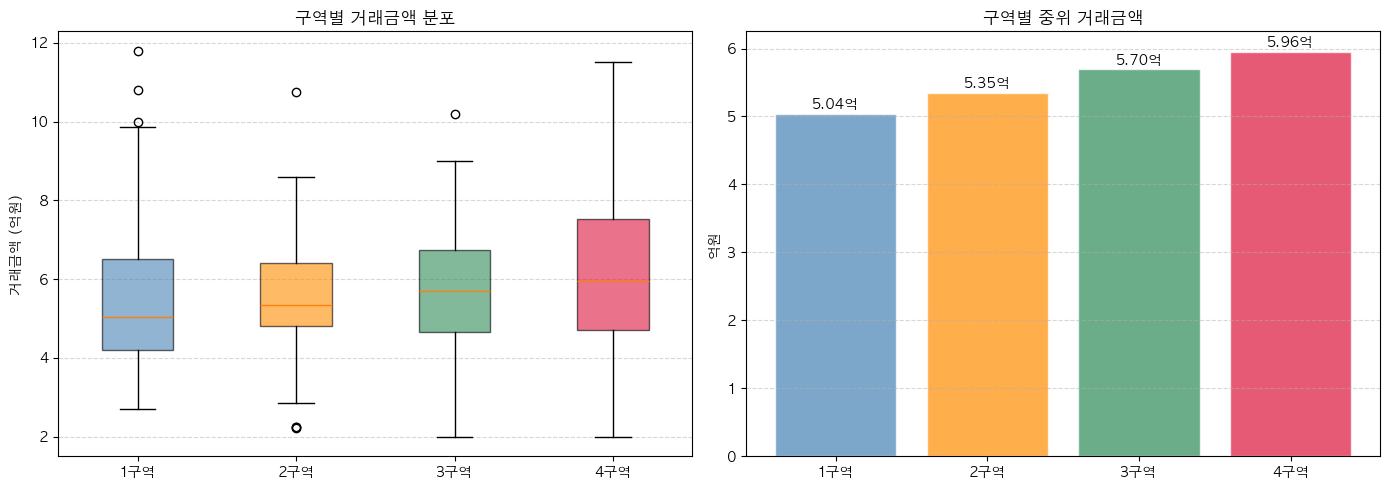

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
data_by_region = [df.filter(pl.col("region") == r)["price"].to_numpy() / 10000 for r in REGIONS]
bp = axes[0].boxplot(data_by_region, labels=REGIONS, patch_artist=True)
for patch, r in zip(bp['boxes'], REGIONS):
    patch.set_facecolor(REGION_COLORS[r])
    patch.set_alpha(0.6)
axes[0].set_title("구역별 거래금액 분포")
axes[0].set_ylabel("거래금액 (억원)")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 구역별 요약 통계
stats = (
    df.group_by("region").agg([
        pl.col("price").median().alias("중위가"),
        pl.col("price").mean().alias("평균가"),
        pl.col("price").min().alias("최소"),
        pl.col("price").max().alias("최대"),
        pl.len().alias("n")
    ]).sort("region")
)
print(stats)

# 구역별 중위가 바차트
med_vals = [df.filter(pl.col("region") == r)["price"].median() / 10000 for r in REGIONS]
bars = axes[1].bar(REGIONS, med_vals, color=[REGION_COLORS[r] for r in REGIONS], alpha=0.7, edgecolor='white')
for bar, v in zip(bars, med_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}억", ha='center', va='bottom', fontsize=10)
axes[1].set_title("구역별 중위 거래금액")
axes[1].set_ylabel("억원")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. 구역별 월별 중위가 트렌드

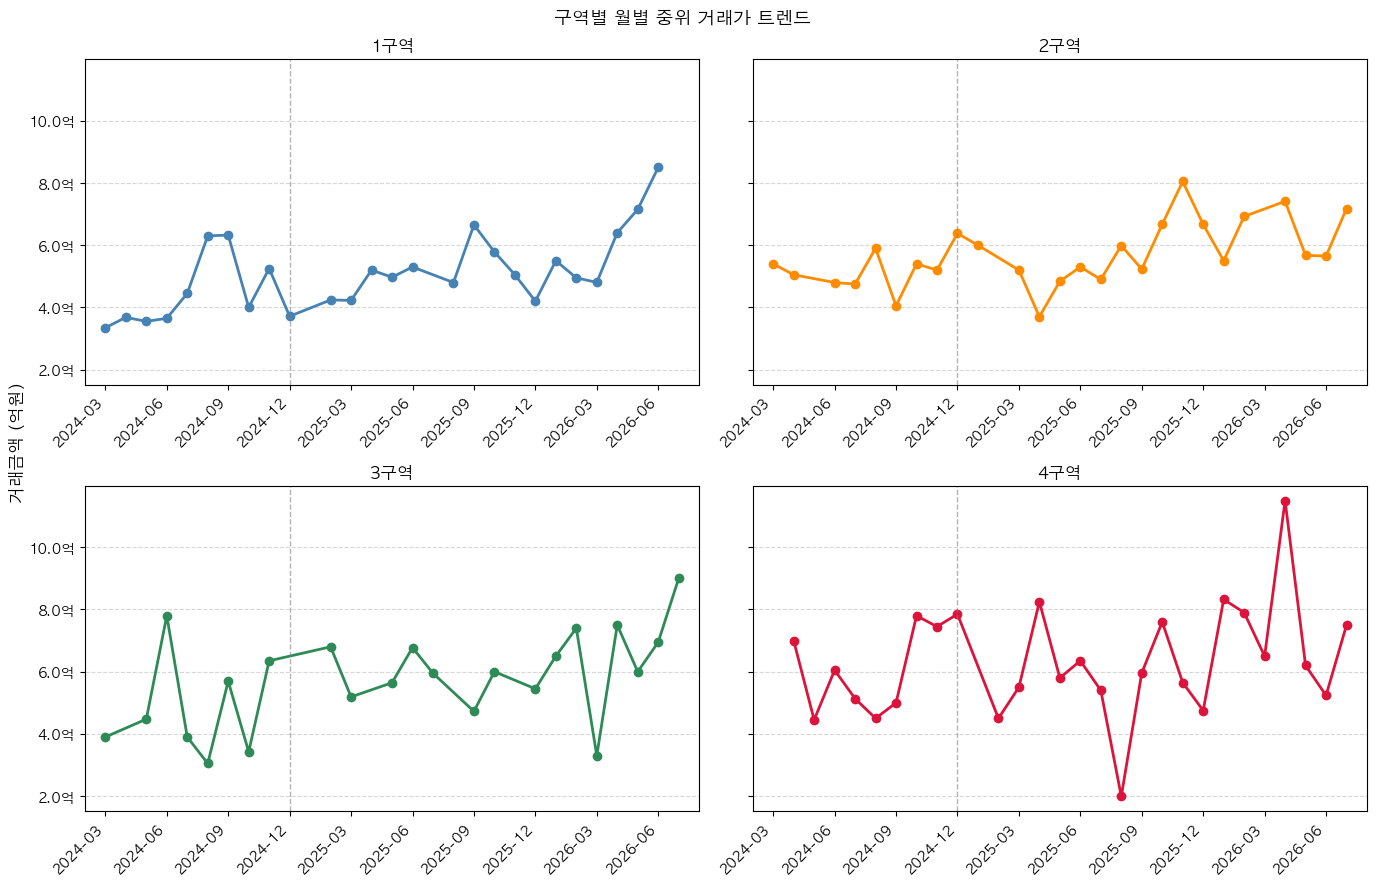

In [4]:
all_ym = df.select("ym").unique().sort("ym")["ym"].to_list()
ym_to_idx = {ym: i for i, ym in enumerate(all_ym)}
quarterly_idx = [i for i, ym in enumerate(all_ym) if ym.endswith(("-03", "-06", "-09", "-12"))]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

for ax, r in zip(axes.flat, REGIONS):
    monthly = (
        df.filter(pl.col("region") == r)
        .group_by("ym").agg(pl.col("price").median().alias("median_price"))
        .sort("ym")
    )
    x = [ym_to_idx[ym] for ym in monthly["ym"].to_list()]
    ax.plot(x, monthly["median_price"].to_numpy() / 10000,
            marker="o", linewidth=2, color=REGION_COLORS[r])
    ax.set_title(r)
    ax.set_xlim(-1, len(all_ym))
    ax.set_xticks(quarterly_idx)
    ax.set_xticklabels([all_ym[i] for i in quarterly_idx], rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f억'))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    if "2024-12" in all_ym:
        ax.axvline(x=all_ym.index("2024-12"), color="gray", linestyle="--", linewidth=1, alpha=0.6)

fig.suptitle("구역별 월별 중위 거래가 트렌드", fontsize=13)
fig.supylabel("거래금액 (억원)")
plt.tight_layout()
plt.show()

## 4. 구역별 ㎡당 가격 비교

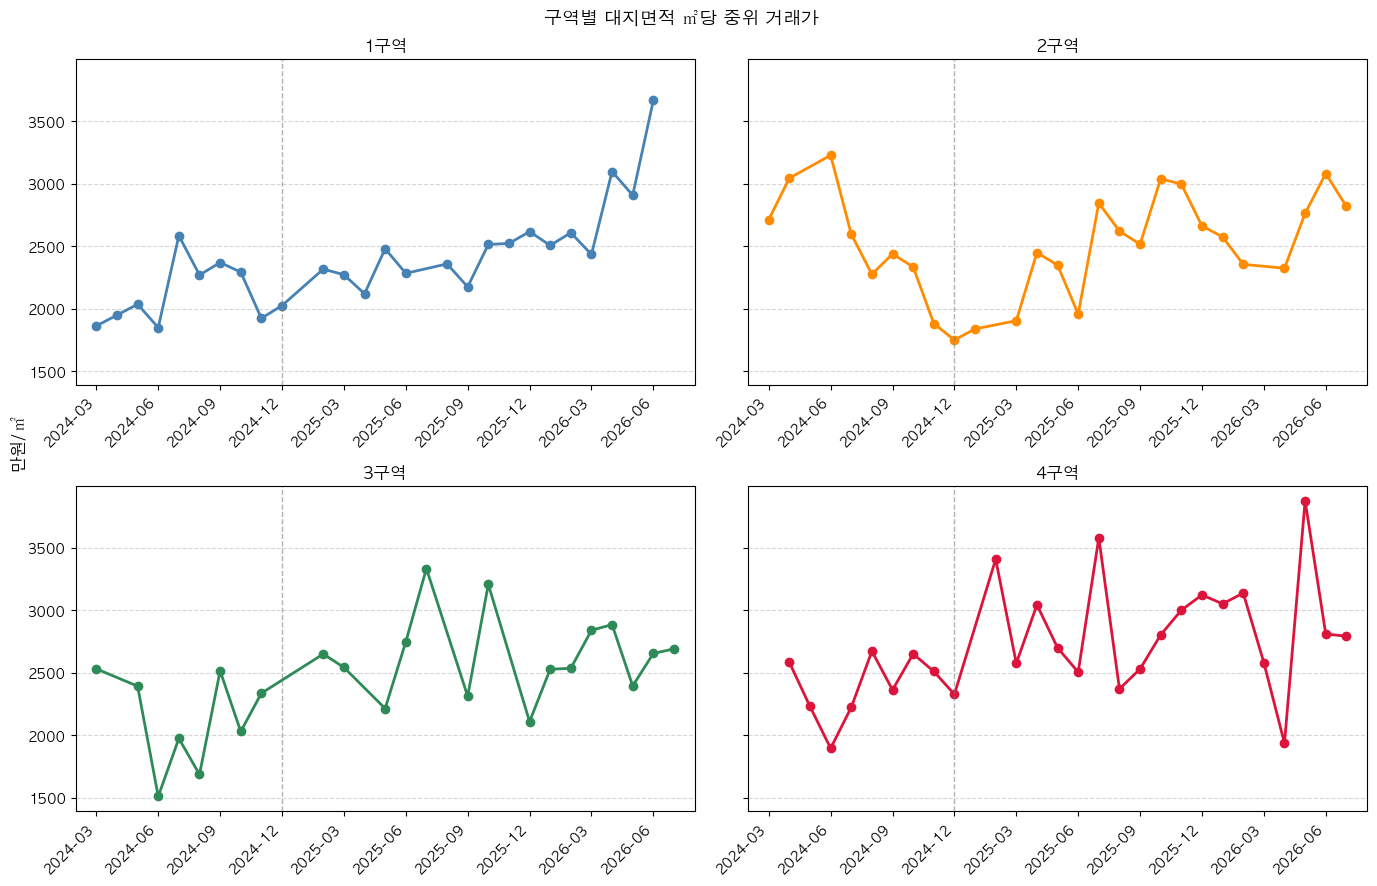

In [5]:
df_ppm = df.with_columns(
    (pl.col("price") / pl.col("land_area")).alias("price_per_land")
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)

for ax, r in zip(axes.flat, REGIONS):
    monthly = (
        df_ppm.filter(pl.col("region") == r)
        .group_by("ym").agg(pl.col("price_per_land").median().alias("med_ppa"))
        .sort("ym")
    )
    x = [ym_to_idx[ym] for ym in monthly["ym"].to_list()]
    ax.plot(x, monthly["med_ppa"].to_numpy(),
            marker="o", linewidth=2, color=REGION_COLORS[r])
    ax.set_title(r)
    ax.set_xlim(-1, len(all_ym))
    ax.set_xticks(quarterly_idx)
    ax.set_xticklabels([all_ym[i] for i in quarterly_idx], rotation=45, ha="right")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    if "2024-12" in all_ym:
        ax.axvline(x=all_ym.index("2024-12"), color="gray", linestyle="--", linewidth=1, alpha=0.6)

fig.suptitle("구역별 대지면적 ㎡당 중위 거래가", fontsize=13)
fig.supylabel("만원/㎡")
plt.tight_layout()
plt.show()

## 5. 구역 고정효과 OLS

구역 더미를 포함한 단일 모델로 구역별 가격 프리미엄과 시간 추세를 동시에 추정

In [6]:
df_ols = df.select(["price", "area", "land_area", "age", "is_basement", "time_idx", "region"]).to_pandas()

# 구역 더미 (1구역 기준)
m_region = smf.ols(
    "price ~ area + land_area + age + is_basement + time_idx + C(region, Treatment('1구역'))",
    data=df_ols
).fit()

print(f"=== 구역 고정효과 OLS (n={len(df_ols)}) ===")
print(f"R²={m_region.rsquared:.4f}  Adj R²={m_region.rsquared_adj:.4f}")
print()

def clean_param_name(name: str) -> str:
    """C(region, Treatment('1구역'))[T.2구역] → 2구역 (vs 1구역)"""
    m = re.search(r"\[T\.(.+?)\]", name)
    return f"{m.group(1)} (vs 1구역)" if m else name

result = pl.DataFrame({
    "변수": [clean_param_name(n) for n in m_region.params.index],
    "계수": m_region.params.values.round(0).tolist(),
    "p-value": m_region.pvalues.values.round(4).tolist(),
    "유의": ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "" for p in m_region.pvalues.values]
})
print(result)

print(f"""
해석 (1구역 기준):
  월 추세       → +{m_region.params['time_idx']:,.0f} 만원/월
  연환산 상승률 → {((1 + m_region.params['time_idx'] / df_ols['price'].median())**12 - 1)*100:.1f}%
""")

=== 구역 고정효과 OLS (n=282) ===
R²=0.6894  Adj R²=0.6803

shape: (9, 4)
┌──────────────────┬──────────┬─────────┬──────┐
│ 변수             ┆ 계수     ┆ p-value ┆ 유의 │
│ ---              ┆ ---      ┆ ---     ┆ ---  │
│ str              ┆ f64      ┆ f64     ┆ str  │
╞══════════════════╪══════════╪═════════╪══════╡
│ Intercept        ┆ 18857.0  ┆ 0.0     ┆ ***  │
│ 2구역 (vs 1구역) ┆ -2011.0  ┆ 0.2053  ┆      │
│ 3구역 (vs 1구역) ┆ 263.0    ┆ 0.8836  ┆      │
│ 4구역 (vs 1구역) ┆ 4033.0   ┆ 0.0163  ┆ *    │
│ area             ┆ 883.0    ┆ 0.0     ┆ ***  │
│ land_area        ┆ 260.0    ┆ 0.0     ┆ ***  │
│ age              ┆ -645.0   ┆ 0.0     ┆ ***  │
│ is_basement      ┆ -14823.0 ┆ 0.0     ┆ ***  │
│ time_idx         ┆ 660.0    ┆ 0.0     ┆ ***  │
└──────────────────┴──────────┴─────────┴──────┘

해석 (1구역 기준):
  월 추세       → +660 만원/월
  연환산 상승률 → 15.7%



## 6. 구역별 시간 추세 비교

구역마다 별도 OLS를 적합하여 월별 상승률 차이를 비교

shape: (4, 7)
┌───────┬─────┬──────────────┬─────────────┬───────────┬─────────┬───────┐
│ 구역  ┆ n   ┆ 월상승(만원) ┆ 월상승률(%) ┆ 연환산(%) ┆ p-value ┆ R²    │
│ ---   ┆ --- ┆ ---          ┆ ---         ┆ ---       ┆ ---     ┆ ---   │
│ str   ┆ i64 ┆ i64          ┆ f64         ┆ f64       ┆ f64     ┆ f64   │
╞═══════╪═════╪══════════════╪═════════════╪═══════════╪═════════╪═══════╡
│ 1구역 ┆ 96  ┆ 818          ┆ 1.62        ┆ 21.3      ┆ 0.0     ┆ 0.845 │
│ 2구역 ┆ 75  ┆ 552          ┆ 1.03        ┆ 13.1      ┆ 0.0     ┆ 0.781 │
│ 3구역 ┆ 47  ┆ 520          ┆ 0.91        ┆ 11.5      ┆ 0.0003  ┆ 0.847 │
│ 4구역 ┆ 64  ┆ 679          ┆ 1.14        ┆ 14.6      ┆ 0.0011  ┆ 0.624 │
└───────┴─────┴──────────────┴─────────────┴───────────┴─────────┴───────┘


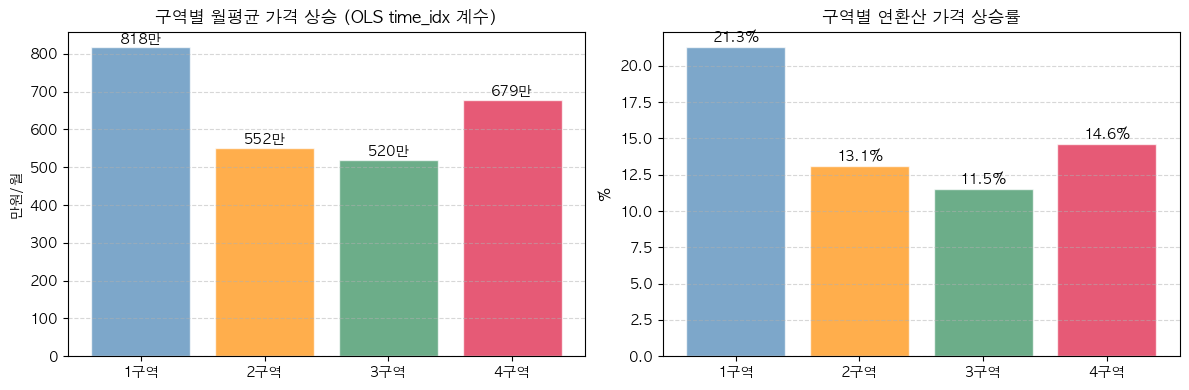

In [7]:
results = []
for r in REGIONS:
    sub = df.filter(pl.col("region") == r).select(["price", "area", "land_area", "age", "is_basement", "time_idx"]).to_pandas()
    if len(sub) < 10:
        continue
    m = smf.ols("price ~ area + land_area + age + is_basement + time_idx", data=sub).fit()
    coef = m.params["time_idx"]
    pval = m.pvalues["time_idx"]
    med_p = sub["price"].median()
    results.append({
        "구역": r,
        "n": len(sub),
        "월상승(만원)": round(coef),
        "월상승률(%)": round(coef / med_p * 100, 2),
        "연환산(%)": round(((1 + coef / med_p) ** 12 - 1) * 100, 1),
        "p-value": round(pval, 4),
        "R²": round(m.rsquared, 3)
    })

summary = pl.DataFrame(results)
print(summary)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

region_labels = summary["구역"].to_list()
monthly_gains = summary["월상승(만원)"].to_list()
annual_rates = summary["연환산(%)"].to_list()
colors = [REGION_COLORS[r] for r in region_labels]

bars1 = axes[0].bar(region_labels, monthly_gains, color=colors, alpha=0.7, edgecolor='white')
for bar, v in zip(bars1, monthly_gains):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:,}만", ha='center', va='bottom', fontsize=10)
axes[0].set_title("구역별 월평균 가격 상승 (OLS time_idx 계수)")
axes[0].set_ylabel("만원/월")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

bars2 = axes[1].bar(region_labels, annual_rates, color=colors, alpha=0.7, edgecolor='white')
for bar, v in zip(bars2, annual_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.1, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_title("구역별 연환산 가격 상승률")
axes[1].set_ylabel("%")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()